<a href="https://colab.research.google.com/github/rtajeong/M3/blob/main/lab15_GD_regression_classification_rev1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Regression (선형회귀)
### Ex1: Linear regression with two variables (y = wx + b)

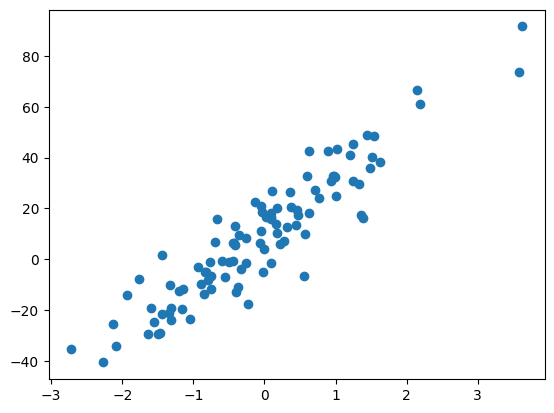

In [1]:
# ex1: linear regression with two variables (y = wx + b)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

n = 100
x = np.random.randn(n)                # batch size
y = x*20 + 10                         # w=20, b=10
y = y + np.random.randn(n) * 10       # add noise

plt.scatter(x,y)

In [2]:
# --------
w=np.random.randn()
b=np.random.randn()

lr = 0.01          # learning rate
n_epoch = 200
lossHistory = []

for epoch in range(n_epoch):
    y_pred = w*x + b
    loss = ((y_pred - y)**2).mean()     # mean square error

    w = w - lr* 2*((y_pred - y)*x).mean()
    b = b - lr* 2*(y_pred - y).mean()
    lossHistory.append(loss)
    if epoch %10 == 0:
        print('epoch=', epoch, 'loss=', loss, 'w=', w, 'b=', b)

print('---------------------------')
print('epoch=', epoch, 'loss=', loss, 'w=', w, 'b=', b)


epoch= 0 loss= 648.4877596295828 w= 1.1249208616694024 b= 1.471365042107293
epoch= 10 loss= 425.6827681233954 w= 5.512096837374414 b= 2.9100830915229015
epoch= 20 loss= 292.25813782552746 w= 8.870429601991379 b= 4.131615499267281
epoch= 30 loss= 212.02060682214596 w= 11.442452515587883 b= 5.16491263916212
epoch= 40 loss= 163.54974350840527 w= 13.413292786732427 b= 6.036168599480208
epoch= 50 loss= 134.12807368460662 w= 14.924302013382261 b= 6.768724550649122
epoch= 60 loss= 116.1788604603845 w= 16.083442423535836 b= 7.38313240408501
epoch= 70 loss= 105.17092843590473 w= 16.973202450725775 b= 7.897315504536854
epoch= 80 loss= 98.3833020011043 w= 17.656630536643856 b= 8.32678276065696
epoch= 90 loss= 94.17479816095539 w= 18.181935474354454 b= 8.684866752291073
epoch= 100 loss= 91.55085164437746 w= 18.585994624326457 b= 8.982966431277765
epoch= 110 loss= 89.90574979120525 w= 18.89702991515275 b= 9.23078214850601
epoch= 120 loss= 88.86868036879555 w= 19.136649568310883 b= 9.436535702758666

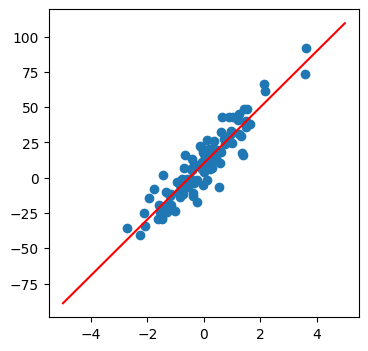

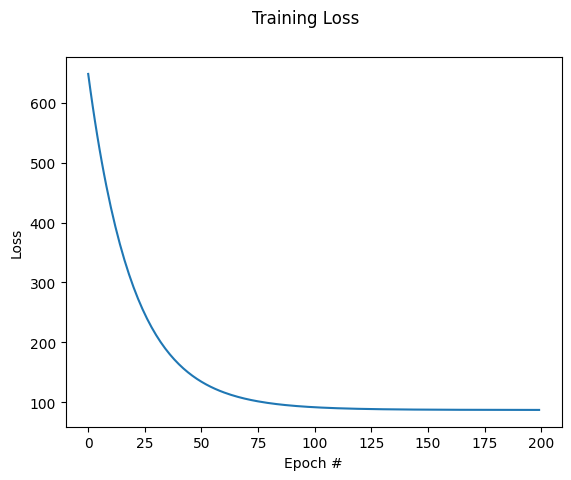

In [3]:

# ------
plt.figure(figsize=(4,4))
plt.scatter(x,y)

xx = np.linspace(-5,5,100)
yy = w * xx + b
plt.plot(xx,yy,c='r')
plt.show()

fig = plt.figure()
plt.plot(np.arange(0, n_epoch), lossHistory)
fig.suptitle("Training Loss")
plt.xlabel("Epoch #")
plt.ylabel("Loss")
plt.show()

### Ex2: Training two features (x1, x2)  ( y = w1*x1 + w2*x2 + b)

In [4]:
# ex 2 : training two parameters w1, w2 and b (y = w1*x1 + w2*x2 + b)

import numpy as np
import pandas as pd

n=100
x1 = np.random.randn(n)             # randn=normal distribution in (-1,1), rand=(0,1)
x2 = np.random.randn(n)

y = x1*30 + x2*40 + 50
y = y + np.random.randn(n)*20      # add noise

#--------------
w1 = np.random.rand()               # initial guess
w2 = np.random.rand()
b = np.random.rand()

lr = 0.02                            # learning rate
n_epoch = 200                      # no of epoch
lossHistory = []

for epoch in range(n_epoch):
    y_pred = w1*x1 + w2*x2 + b
    error = ((y_pred - y)**2).mean() # MSE

    w1 = w1 - lr* 2* ((y_pred - y)*x1).mean()
    w2 = w2 - lr* 2 *((y_pred - y)*x2).mean()
    b = b - lr* 2* (y_pred - y).mean()
    lossHistory.append(error)

print('---------------------------')
print('epoch=', epoch, 'error=', error, 'w1=', w1.round(2), 'w2=', w2.round(2), 'b=', b.round(2))

---------------------------
epoch= 199 error= 490.20497750449204 w1= 30.46 w2= 38.21 b= 47.25


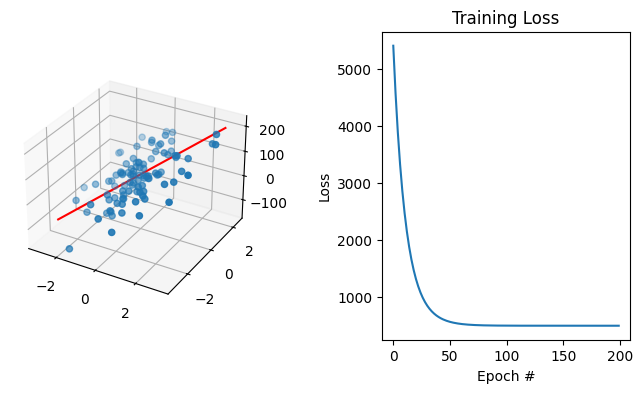

In [5]:
# w1, w2, b = model.coef_[0], model.coef_[1], model.intercept_

plt.figure(figsize = (8,4))
ax1 = plt.subplot(121, projection='3d')
ax1.scatter3D(x1, x2, y);

xx = np.linspace(-3,3,100)
yy = np.linspace(-2,2,100)
zz = w1*x1 + w2*x2 + b
ax1.plot(xx, yy, w1*xx + w2*yy + b, c='r')

ax2 = plt.subplot(122)
ax2.plot(np.arange(0, n_epoch), lossHistory)
ax2.set_title("Training Loss")
ax2.set_xlabel("Epoch #")
ax2.set_ylabel("Loss")

plt.subplots_adjust(wspace=0.5)
plt.show()

### Ex3: Using regression function (LinearRegression)

In [6]:
# ex3: using regression function (LinearRegression)

from sklearn.linear_model import LinearRegression, SGDRegressor

# X = pd.DataFrame(x1)
# X[1] =x2

X = np.concatenate([x1.reshape(n,1), x2.reshape(n,1)], axis=1)

model = SGDRegressor()        # create model
model.fit(X,y)                    # train model
print("score: ",model.score(X,y))
print('w1=', model.coef_[0], 'w2=', model.coef_[1], 'b=', model.intercept_)


score:  0.8716078702539645
w1= 30.466741988504204 w2= 38.208404112551264 b= [47.28107738]


In [7]:

# ------
# prediction
new_X=[1,3]
print(model.predict([new_X]))

z=np.random.rand(10,2)
print(model.predict(z))

[192.37303171]
[ 70.15225551  51.50785715 106.16269301  78.35096565  77.60516189
  89.39301841  77.54006321  83.6737519   69.40638778  82.25411806]


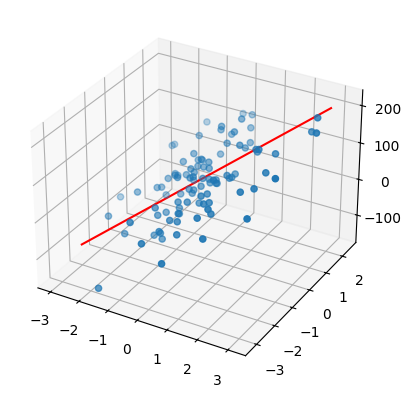

In [8]:
# from mpl_toolkits import mplot3d

w1, w2, b = model.coef_[0], model.coef_[1], model.intercept_

fig = plt.figure()
ax = plt.axes(projection='3d')
ax.scatter3D(x1, x2, y);

xx = np.linspace(-3,3,100)
yy = np.linspace(-2,2,100)
zz = w1*x1 + w2*x2 + b
ax.plot(xx, yy, w1*xx + w2*yy + b, c='r')

### Ex4: Use make_regression

In [9]:
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

X, y = make_regression(n_samples=2000, n_features=2, noise=1.5, random_state=1)
X = StandardScaler().fit_transform(X)
print(X[:5], y[:5])

[[ 0.33762316 -0.38981751]
 [-1.02672037  2.22938631]
 [ 0.09896413  0.63153974]
 [ 3.97755099 -1.64591196]
 [ 1.14153039 -0.70330793]] [-26.77111241 176.82634938  55.25266631 -79.36653137 -41.50945283]


In [10]:
model = SGDRegressor()         # create model
model.fit(X,y)                    # train model
print(model.coef_, model.intercept_)
model.score(X,y)

[15.07119882 85.46081902] [1.42662625]


0.9996930253897062

In [11]:
model.coef_, model.intercept_

(array([15.07119882, 85.46081902]), array([1.42662625]))

In [12]:
model = LinearRegression()        # create model
model.fit(X,y)                    # train model
print(model.coef_, model.intercept_)
model.score(X,y)

[15.04988322 85.45534012] 1.4061674990019462


0.9996931455705321

## Ex5: OLS (Ordinary Least Squares)
- use Normal equation: y = XW
  - W* = (X_{T}X){-1}X{T}y

In [13]:
# normal equation

X_b = np.concatenate([X, np.ones((X.shape[0], 1))], axis=1)
w_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
print("weight: ", w_best[:-1], "bias: ", w_best[-1])

weight:  [15.04988322 85.45534012] bias:  1.4061674990019402


In [14]:
model = LinearRegression()        # create model
model.fit(X,y)                    # train model
print(model.coef_, model.intercept_)

[15.04988322 85.45534012] 1.4061674990019462


In [15]:
# prediction and evaluation
from sklearn.metrics import r2_score

X_b = np.concatenate([X, np.ones((X.shape[0], 1))], axis=1)
y_hat = X_b.dot(w_best)
r2_score(y, y_hat)

0.9996931455705321

# Classification (선형분류)
- Linear classification with two variables
- Logistic Regression
- using CrossEntropy  as loss function
- number of features = 2

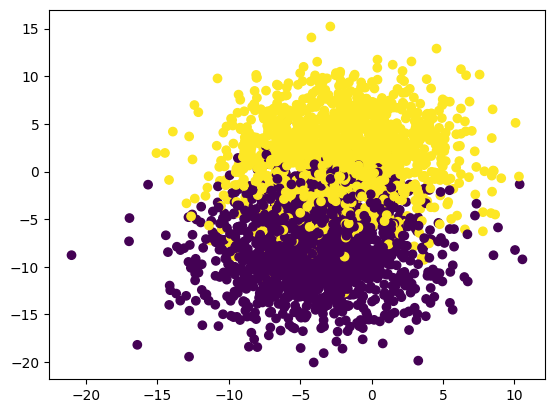

In [16]:
from sklearn.datasets import make_blobs

N = 3000
(X, y) = make_blobs(n_samples=N, n_features=2, centers=2, cluster_std=4.0)
x1, x2 = X[:,0], X[:,1]
plt.scatter(X[:,0], X[:,1], c=y)

In [17]:
w1 = np.random.randn()   # initial W value
w2 = np.random.randn()   # initial W value
b = np.random.randn()   # initial b value

def sigmoid_activation(x):
    return 1.0 / (1 + np.exp(-x))

lossHistory = []
epochs = 300
lr = 0.01

for epoch in np.arange(epochs):
    preds = sigmoid_activation(w1*x1 + w2*x2 + b)       # prediction (Prob[class=1])
    # error = preds - y
    loss = -((y*np.log(preds) + (1-y)*np.log(1-preds))).mean()  # log loss = cross entropy
    lossHistory.append(loss)

    dloss_dz = preds - y
    w1_deriv = dloss_dz * x1        # d(loss)/dw1 = d(loss)/dz * dz/dw1
    w2_deriv = dloss_dz * x2
    b_deriv = dloss_dz * 1

    w1 = w1 - (lr * w1_deriv).mean()
    w2 = w2 - (lr * w2_deriv).mean()
    b  = b  - (lr * b_deriv).mean()

print(w1, w2, b)
accuracy = ((sigmoid_activation(w1*x1 + w2*x2 + b) > 0.5) == y).sum()/N
print(accuracy)

-0.14026786438229252 0.4003973502808517 -0.33101911202735124
0.801


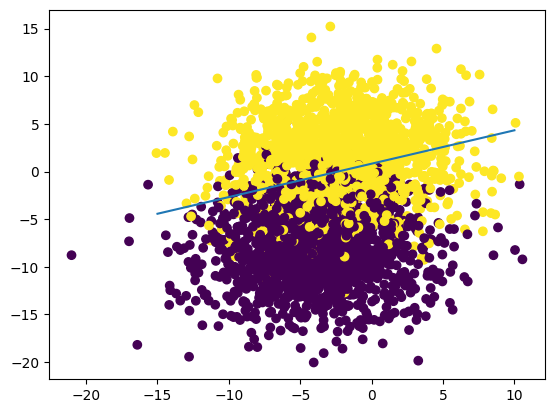

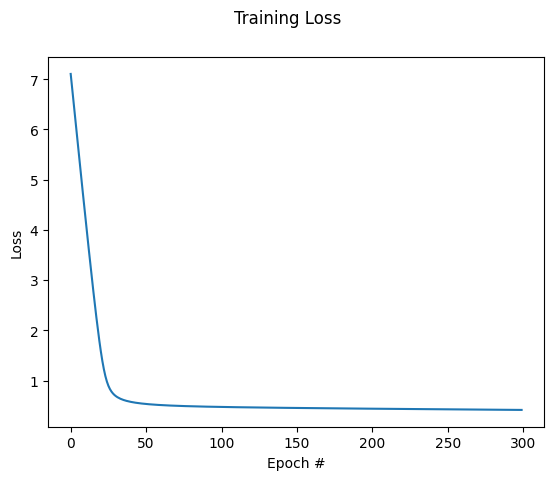

In [18]:
#plt.ylim([-12,10])
plt.scatter(X[:,0], X[:,1], c=y)
xx = np.linspace(-15,10,100)
yy = -w1/w2 * xx - b/w2
plt.plot(xx, yy)
plt.show()

# construct a figure that plots the loss over time
fig = plt.figure()
plt.plot(lossHistory)
# plt.ylim([-10.,10.])
fig.suptitle("Training Loss")
plt.xlabel("Epoch #")
plt.ylabel("Loss")
plt.show()

#### Ex3: use library functions

[[0.08191776 1.02354622]] [3.0515836]
Score:  0.8956666666666667


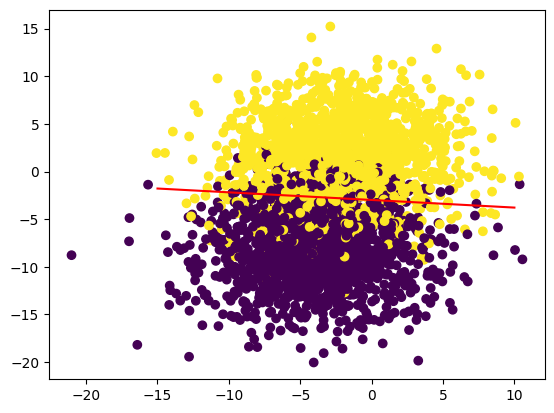

In [19]:
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.datasets import make_blobs

clf = SGDClassifier()
clf.fit(X[:,:2], y)
print(clf.coef_, clf.intercept_)
print("Score: ", clf.score(X[:,:2], y))

w1, w2, b = clf.coef_[0,0], clf.coef_[0,1], clf.intercept_
xx = np.linspace(-15,10,100)
yy = -w1/w2 * xx -b/w2
plt.plot(xx, yy, c='r')
plt.scatter(X[:,0], X[:,1], c=y)

Logistic Regression:  0.895
[[0.09149328 0.60967751]] [2.2704032]
Score:  0.895


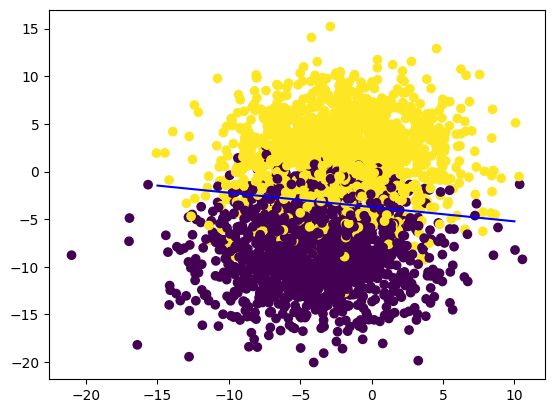

In [20]:
log = LogisticRegression()
log.fit(X[:,:2], y)
print("Logistic Regression: ", log.score(X[:, :2],y))
print(log.coef_, log.intercept_)
print("Score: ", log.score(X[:,:2], y))
plt.scatter(X[:,0], X[:,1], c=y)

w1, w2, b = log.coef_[0,0], log.coef_[0,1], log.intercept_
xx = np.linspace(-15,10,100)
yy = -w1/w2 * xx -b/w2
plt.plot(xx, yy, c='b')

- end -